# Image Recon Comparison Dataset

This notebook creates a synthetic dataset for comparing image reconstruction algorithms.

Resting state data recorded with a whole-head ninjaNIRS is augmented with synthetic activations with a known spatial and temporal pattern.

The activations are located below C3 and C4, with a Gaussian profile that decays as a function of geodesic distance. The temporal shape
follows a canonical Gamma HRF form.

In [1]:
import random
from pathlib import Path

import cedalion.dataclasses as cdc
import cedalion.dot
import cedalion.models.glm as glm
import cedalion.sigproc.quality as quality
import cedalion.sim.synthetic_hrf as synhrf
import cedalion.vis.anatomy
import cedalion.vis.blocks as vbx
import cedalion.vis.quality
import matplotlib.pyplot as p
import numpy as np
import pyvista as pv
import xarray as xr
from cedalion import units

xr.set_options(display_expand_data=False)

In [2]:
OUTPUT_FOLDER = Path("/home/eike/Projekte/ibslab/40_analysis/img_space_std_comparison")

Load the ICBM-152 head model

In [3]:
head_ijk = cedalion.dot.get_standard_headmodel("icbm152")
head_ras = head_ijk.apply_transform(head_ijk.t_ijk2ras)
inflated = cedalion.dot.get_inflated_cortex_surface("icbm152")

Load a NinjaNirs-22 resting state dataset

In [4]:
rec = cedalion.data.get_nn22_resting_state()
rec["amp_repaired"] = quality.repair_amp(rec["amp"])
rec["od"] = cedalion.nirs.cw.int2od(rec["amp_repaired"])

Data Quality Inspection. 

SCI and PSP metrics are calculated for 5s time windows, which are considered clean if both metrics are above given thresholds. A whole channel is considered clean, if 75% of all time windows are clean.

List of pruned channels: ['S6D66' 'S6D1' 'S26D3' 'S25D13' 'S5D139' 'S3D68' 'S14D95' 'S2D140'
 'S2D36' 'S1D38' 'S1D65' 'S1D67' 'S32D69' 'S32D72' 'S32D67' 'S32D2'
 'S31D9' 'S3D66' 'S3D67' 'S4D65' 'S4D36' 'S1D69' 'S2D38' 'S7D39' 'S1D39'
 'S6D3' 'S6D70' 'S32D70' 'S40D46' 'S39D46' 'S30D16' 'S35D16' 'S43D56'
 'S42D55' 'S45D115' 'S18D115' 'S18D74' 'S16D103' 'S23D103' 'S20D103'
 'S43D113' 'S43D55' 'S45D50' 'S45D56' 'S21D78' 'S24D98' 'S19D77' 'S44D115'
 'S44D53' 'S44D54' 'S42D116' 'S28D16' 'S23D81' 'S6D17' 'S53D22' 'S49D122'
 'S51D122' 'S55D122' 'S49D124' 'S54D130' 'S55D131' 'S51D24' 'S17D112'
 'S49D106' 'S48D32' 'S46D127' 'S47D115' 'S47D25' 'S38D126' 'S39D121']  (70)


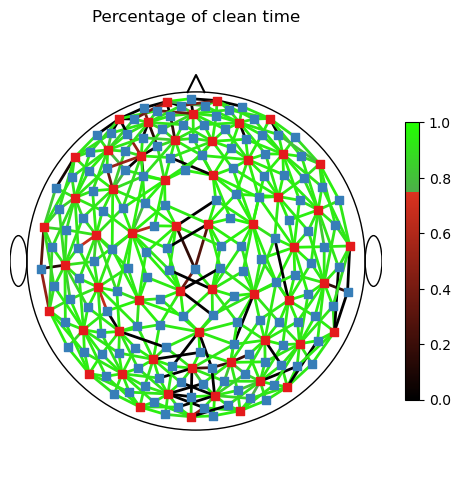

In [5]:
window_length = 5 * units.s
sci_thresh = 0.75
psp_thresh = 0.1
sci_psp_percentage_thresh = 0.75

sci, sci_mask = quality.sci(rec["od"], window_length, sci_thresh)
psp, psp_mask = quality.psp(rec["od"], window_length, psp_thresh)
sci_x_psp_mask = sci_mask & psp_mask

perc_time_clean = sci_x_psp_mask.sum(dim="time") / len(sci.time)
sci_psp_mask = [perc_time_clean >= sci_psp_percentage_thresh]

f,ax = p.subplots(1,1,figsize=(6,6))

norm, cmap = cedalion.vis.colors.threshold_cmap(
    "perc_clean_time",
    0,
    1,
    threshold=sci_psp_percentage_thresh,
    higher_is_better=True,
    colors=["#000000", "#DC3220", "#4daf4a", "#22ff00"],
)

cedalion.vis.anatomy.scalp_plot(
    rec["od"],
    rec.geo3d,
    perc_time_clean,
    ax,
    title = "Percentage of clean time",
    cmap=cmap, norm = norm,
)

# Prune channels that do not pass the quality test
rec["od_clean"], drop_list = quality.prune_ch(rec["od"], sci_psp_mask, "all")

# Display pruned channels
print(f"List of pruned channels: {drop_list}  ({len(drop_list)})")

OD_NAME = "od_clean"

Register montage to scalp

In [6]:
geo3d_relaxed, _ = head_ras.align_and_relax_to_scalp(rec.geo3d, rec["amp"])

Visualize registered montage

In [7]:
plt = pv.Plotter()
vbx.plot_surface(plt, head_ras.scalp, color="w")
vbx.plot_labeled_points(plt, geo3d_relaxed)
plt.show()

Widget(value='<iframe src="http://localhost:41243/index.html?ui=P_0x727edf14d650_0&reconnect=auto" class="pyvi…

Load precomputed sensitivity matrix. Keep only brain vertices as no activation in scalp tissue is simulated.

In [8]:
Adot = cedalion.data.get_precomputed_sensitivity("nn22_resting", "icbm152")
Adot_brain = Adot.sel(vertex=Adot.is_brain, channel=rec[OD_NAME].channel)
Adot_brain

<xarray.DataArray (channel: 497, vertex: 25000, wavelength: 2)> Size: 99MB
2.339e-17 2.339e-17 6.079e-17 6.079e-17 ... 1.661e-24 2.084e-09 2.084e-09
Coordinates:
    parcel      (vertex) object 200kB 'VisCent_Striate_2_LH' ... 'SalVentAttn...
    is_brain    (vertex) bool 25kB True True True True ... True True True True
  * channel     (channel) object 4kB 'S10D87' 'S10D94' ... 'S47D29' 'S5D137'
    detector    (channel) object 4kB 'D87' 'D94' 'D89' ... 'D129' 'D29' 'D137'
    source      (channel) object 4kB 'S10' 'S10' 'S10' ... 'S56' 'S47' 'S5'
  * wavelength  (wavelength) float64 16B 760.0 850.0
Dimensions without coordinates: vertex
Attributes:
    units:    mm

## Generate spatial activation patterns

The simulated patterns are Gaussians with their maximum directly below C3 or C4 and decaying as a function of geodesic distance.

In [9]:
# obtain the closest vertices to C3 and C4
_, c3_seed = head_ras.brain.mesh.kdtree.query(
    head_ras.landmarks.sel(label="C3").pint.magnitude
)
_, c4_seed = head_ras.brain.mesh.kdtree.query(
    head_ras.landmarks.sel(label="C4").pint.magnitude
)

# create the spatial activations below both landmarks
spatial_act_c3 = synhrf.build_spatial_activation(
    head_ras.brain,
    c3_seed,
    spatial_scale=2 * cedalion.units.cm,
    intensity_scale=5 * units.micromolar,
    hbr_scale=-0.4,
)

spatial_act_c4 = synhrf.build_spatial_activation(
    head_ras.brain,
    c4_seed,
    spatial_scale=2 * cedalion.units.cm,
    intensity_scale=5 * units.micromolar,
    hbr_scale=-0.4,
)

# concatenate the two spatial activations along a new dimension
spatial_act = xr.concat(
    [spatial_act_c3, spatial_act_c4], dim="trial_type"
).assign_coords(trial_type=["Stim C3", "Stim C4"])
spatial_act

Magnitude,[[[5.7040239364296656e-24 -2.2816095745718667e-24] [5.405644054887741e-23 -2.1622576219550965e-23] [5.416602439525968e-23 -2.1666409758103877e-23] ... [0.0 -0.0] [0.0 -0.0] [0.0 -0.0]] [[0.0 -0.0] [0.0 -0.0] [0.0 -0.0] ... [2.338041613242997e-08 -9.352166452971988e-09] [4.6530581085109773e-26 -1.8612232434043912e-26] [1.1578686038993637e-12 -4.631474415597455e-13]]]
Units,molar


Visualize spatial activation patterns

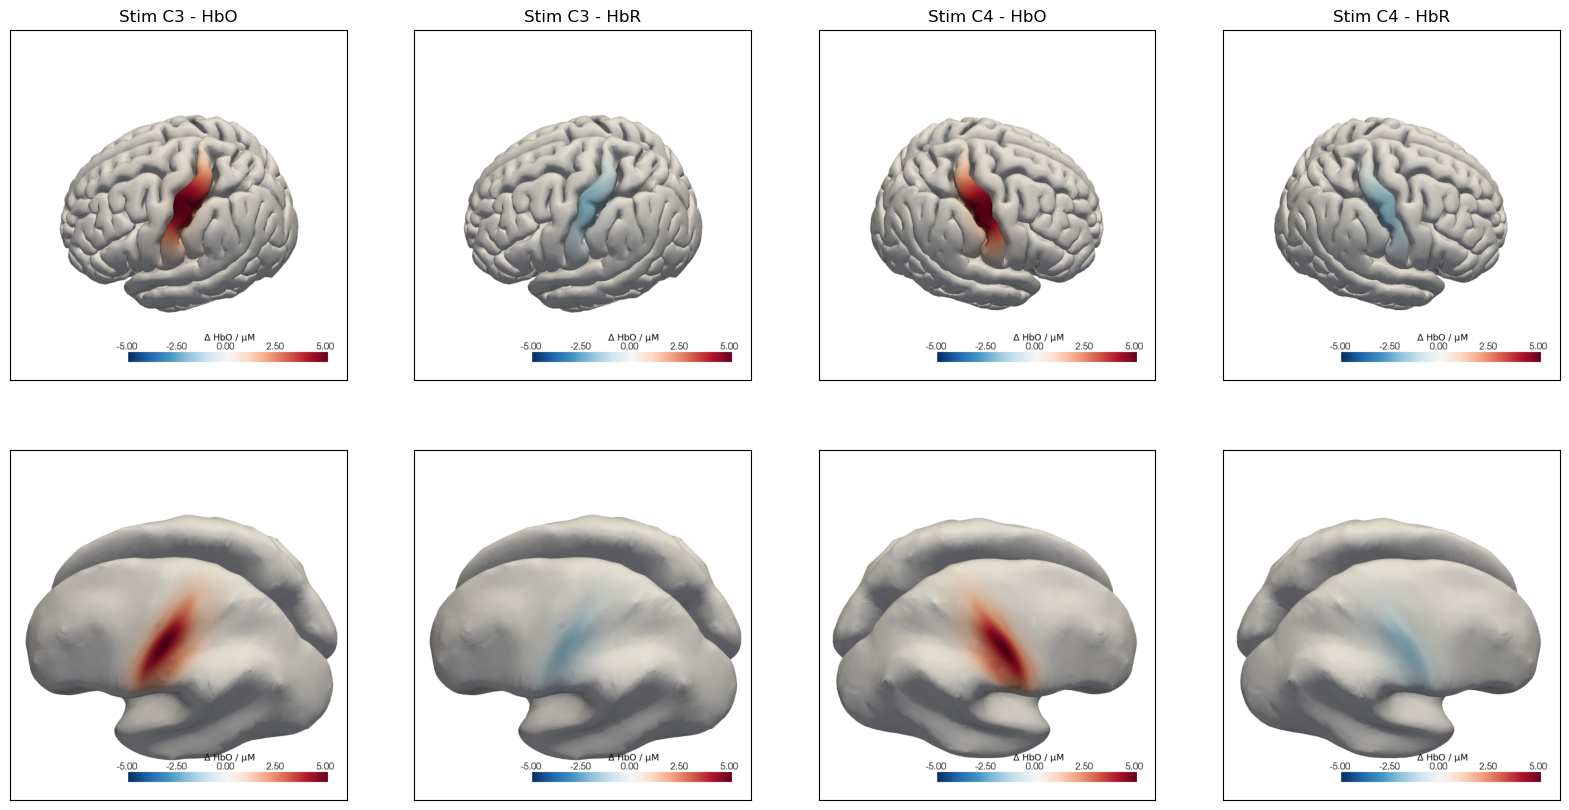

In [10]:
kwargs = dict(
    cmap="RdBu_r",
    vmin=-5,
    vmax=+5,
    cb_label=r"$\Delta$ HbO / µM",
    title=None,
)

f, ax = p.subplots(2, 4, figsize=(20, 10))

for i, pos in enumerate(["C3", "C4"]):
    for j, chromo in enumerate(["HbO", "HbR"]):
        ax_col = 2 * i + j
        trial_type = f"Stim {pos}"

        ax[0, ax_col].set_title(f"{trial_type} - {chromo}")
        cedalion.vis.anatomy.plot_brain_in_axes(
            rec[OD_NAME],
            head_ras.landmarks,
            spatial_act.sel(trial_type=trial_type, chromo=chromo).pint.to("uM"),
            head_ras.brain,
            ax[0, ax_col],
            camera_pos=pos,
            **kwargs,
        )

        cedalion.vis.anatomy.plot_brain_in_axes(
            rec[OD_NAME],
            head_ras.landmarks,
            spatial_act.sel(trial_type=trial_type, chromo=chromo).pint.to("uM"),
            inflated,
            ax[1, ax_col],
            camera_pos=pos,
            **kwargs,
        )

Store the spatial activation patterns in a csv file:

In [11]:
df_spatial_act = spatial_act.pint.to("uM").pint.dequantify().to_dataframe("spatial_act")
display(df_spatial_act)
df_spatial_act.to_csv(OUTPUT_FOLDER / "spatial_act.csv")

spatial_act
trial_type vertex chromo              
Stim C3    0      HbO     5.704024e-18
                  HbR    -2.281610e-18
           1      HbO     5.405644e-17
                  HbR    -2.162258e-17
           2      HbO     5.416602e-17
...                                ...
Stim C4    24997  HbR    -9.352166e-03
           24998  HbO     4.653058e-20
                  HbR    -1.861223e-20
           24999  HbO     1.157869e-06
                  HbR    -4.631474e-07

[100000 rows x 1 columns]

Using the sensitivity matrix, transfer the activation to channel space.

In [12]:
max_od_per_channel = cedalion.dot.forward_model.image_to_channel_space(
    Adot_brain, spatial_act, spectrum="prahl"
)
max_od_per_channel

Magnitude,[[[-8.02479831146082e-12 -2.343544738498611e-10 -3.946934239398954e-11 ... -2.5190140817132026e-13 -2.0854502294854987e-14 -2.083204897583162e-14] [1.8771417582776078e-10 5.481964181884299e-09 9.232574814210377e-10 ... 5.892417901294875e-12 4.878235637381567e-13 4.872983410333149e-13]] [[-0.00015270810683315538 -4.896177230036805e-06 -1.0821581450553755e-06 ... -9.942684904738198e-08 -6.803374445934713e-10 -7.744133204382239e-10] [0.0035721117595519983 0.00011453021468843255 2.5313586264749617e-05 ... 2.325769234277844e-06 1.5914291891203574e-08 1.8114892431439116e-08]]]
Units,dimensionless


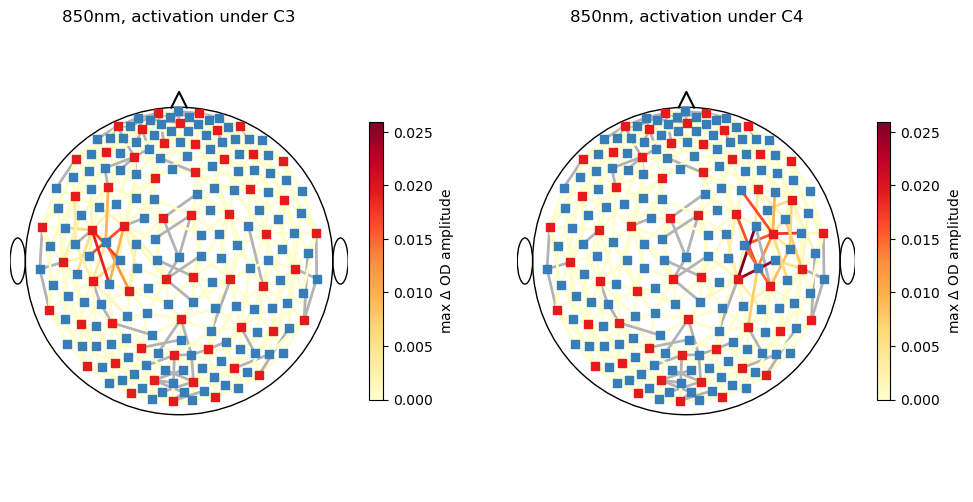

In [13]:
fig, ax = p.subplots(1, 2, figsize=(12,6))

for i, pos in enumerate(["C3", "C4"]):
    trial_type = f"Stim {pos}"
    wl = 850
    cedalion.vis.anatomy.scalp_plot(
        rec["od"],
        geo3d_relaxed,
        max_od_per_channel.sel(trial_type=trial_type, wavelength=wl),
        ax[i],
        cmap="YlOrRd",
        title=f"850nm, activation under {pos}",
        vmin = 0,
        vmax=max_od_per_channel.max().item(),
        cb_label="max $\Delta$ OD amplitude",
        optode_labels=False,
    )

Find the two channels with the highest activation for activations below C3 and C4

In [14]:
ch_c3 = max_od_per_channel.channel.values[np.argmax(np.abs(max_od_per_channel.loc["Stim C3",760,:].values))]
ch_c4 = max_od_per_channel.channel.values[np.argmax(np.abs(max_od_per_channel.loc["Stim C4",760,:].values))]
display((ch_c3, ch_c4))

/opt/miniconda3/envs/cedalion_260507/lib/python3.11/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


('S25D28', 'S46D112')

## Generate temporal activation patterns

Use a canonical Gamma HRF shape:

In [15]:
basis_fct = glm.Gamma(tau=0 * units.s, sigma=3 * units.s, T=3 * units.s)

The dataset contains about 6 min. of resting state data:

In [16]:
rec[OD_NAME].time

<xarray.DataArray 'time' (time: 3309)> Size: 26kB
0.0 0.1112 0.2225 0.3337 0.445 0.5562 ... 367.5 367.6 367.7 367.8 367.9 368.0
Coordinates:
  * time     (time) float64 26kB 0.0 0.1112 0.2225 0.3337 ... 367.8 367.9 368.0
    samples  (time) int64 26kB 0 1 2 3 4 5 6 ... 3303 3304 3305 3306 3307 3308
Attributes:
    units:    second

Generate randomly distributed stimulus events covering the whole time range

In [17]:
random.seed(42)

df_stim = synhrf.build_stim_df(
    max_time=rec["od"].time.values[-1] * units.seconds,
    trial_types=["Stim C3", "Stim C4"],
    min_interval=10 * units.seconds,
    max_interval=20 * units.seconds,
    min_stim_dur = 10 * units.seconds,
    max_stim_dur = 10 * units.seconds,
    min_stim_value = 1.0,
    max_stim_value = 1.0,
    order="random",
)

print(f"generated {len(df_stim)} events.")
df_stim

generated 14 events.


,onset,duration,value,trial_type
0,16.39,10.0,1.0,Stim C3
1,38.62,10.0,1.0,Stim C4
2,59.49,10.0,1.0,Stim C3
3,84.54,10.0,1.0,Stim C3
4,109.99,10.0,1.0,Stim C4
5,130.05,10.0,1.0,Stim C4
6,151.60,10.0,1.0,Stim C3
7,172.57,10.0,1.0,Stim C4
8,199.87,10.0,1.0,Stim C4
9,225.39,10.0,1.0,Stim C4


We can now use our stim dataframe, basis function, and spatial information to create the synthetic HRF timeseries

In [18]:
syn_ts = synhrf.build_synthetic_hrf_timeseries(rec[OD_NAME], df_stim, basis_fct, max_od_per_channel)
syn_ts

Magnitude,[[[[-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] ... [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]]] [[[-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] ... [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] ... [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]]]]
Units,dimensionless


Add resting-state and synthetic time series:

In [19]:
rec["od_augm"] = rec[OD_NAME] + syn_ts

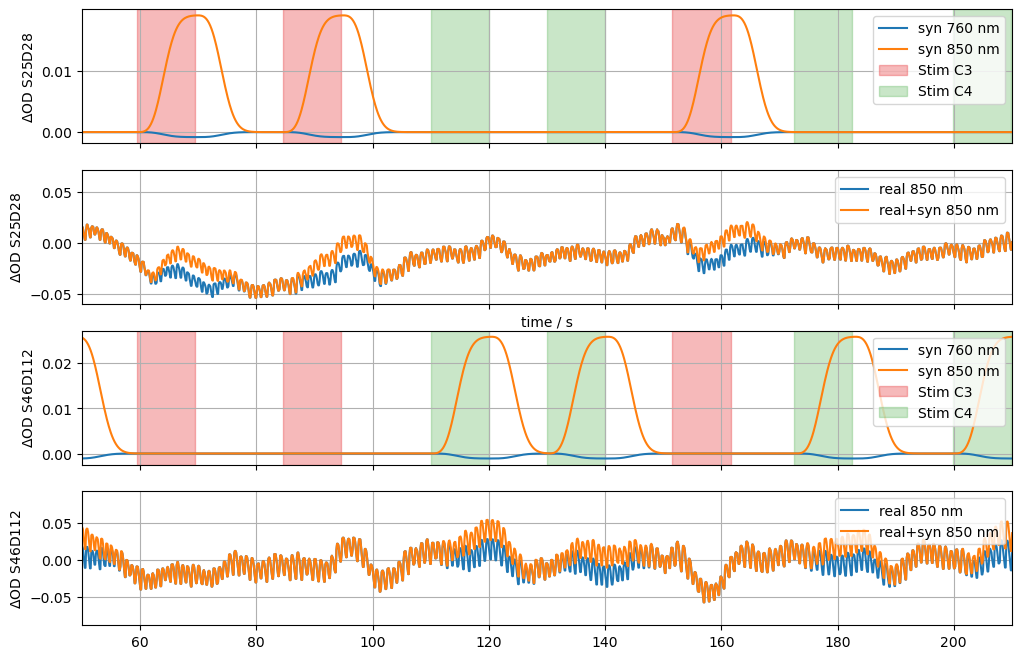

In [20]:
f, ax = p.subplots(4,1, figsize=(12,8), sharex=True)
for i, (trial_type,ch) in enumerate([("Stim C3", ch_c3), ("Stim C4", ch_c4)]):
    for wl in [760., 850.]:
        ax[2*i].plot(syn_ts.time, syn_ts.sel(trial_type=trial_type, channel=ch, wavelength=wl), label=f"syn {wl:.0f} nm")
    
    vbx.plot_stim_markers(ax[2*i], df_stim, y=1.)

    wl = 850.    
    ax[2*i+1].plot(rec[OD_NAME].time, rec[OD_NAME].sel(channel=ch, wavelength=wl), label=f"real {wl:.0f} nm")
    ax[2*i+1].plot(rec["od_augm"].time, rec["od_augm"].sel(trial_type=trial_type, channel=ch, wavelength=wl), label=f"real+syn {wl:.0f} nm")

    
    ax[2*i].legend(loc="upper right")
    ax[2*i+1].legend(loc="upper right")
    ax[2*i].grid()
    ax[2*i+1].grid()
    ax[2*i].set_ylabel(f"$\Delta$OD {ch}")
    ax[2*i+1].set_ylabel(f"$\Delta$OD {ch}")
ax[1].set_xlabel("time / s");
ax[-4].set_xlim(50,210);

## Estimating HRF in channel space through block averaging

In [21]:
# apply a frequency filter
rec["od_augm_filtered"] = rec["od_augm"].cd.freq_filter(fmin=0.02, fmax=0.5, butter_order=4)

# split epochs
epochs = rec["od_augm_filtered"].cd.to_epochs(
    df_stim,  # stimulus dataframe
    ["Stim C3", "Stim C4"],  # select events
    before=1 * units.seconds,  # seconds before stimulus
    after=20 * units.seconds,  # seconds after stimulus
)

# calculate baseline
baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")

# subtract baseline
epochs_blcorrected = epochs - baseline

# group trials by trial_type. For each group individually average the epoch dimension
blockaverage = epochs_blcorrected.groupby("trial_type").mean("epoch")
display(blockaverage)

Magnitude,[[[[-0.00019915819926659257 -0.00019916470844967872] [-0.00018006825098576253 -0.00018007296872237993] [-0.00014468446321316142 -0.00014468748662126027] ... [0.0017153993453994868 0.0017155022678839295] [0.0017843165959248195 0.0017844206254406837] [0.0018362543649706534 0.001836359293602963]] [[-0.00028485944883856006 -0.00028470718757385785] [-0.00023860226864167537 -0.00023849191246724954] [-0.00017610184004345872 -0.00017603111719930204] ... [0.0022115861013148707 0.002209178563006776] [0.0023093276921014724 0.0023068942583773133] [0.0023876000076305933 0.0023851455419881353]]] [[[-0.00033547774847055717 -0.00033547789955004365] [-0.00027870657837258245 -0.0002787066878722259] [-0.00020450925545339 -0.00020450932562731788] ... [0.0012805432033314954 0.0012805455921844784] [0.0013422834193749964 0.0013422858339223992] [0.0013819214795026753 0.0013819239149187503]] [[-0.00045080125160321414 -0.00045079771758784647] [-0.0003674378746165143 -0.0003674353132269278] [-0.00026513987215409516 -0.00026513823066227904] ... [0.0016351550799018587 0.0016350992004182453] [0.0016919745040842138 0.0016919180235627535] [0.0017301858705890212 0.0017301289019124612]]] [[[-0.00021356596050394792 -0.0002135679190954259] [-0.0001762948716128234 -0.00017629629116403556] [-0.00012812173286223797 -0.00012812264259565127] ... [0.0011888893636184678 0.0011889203326500392] [0.0012953614156400884 0.0012953927177737252] [0.001397320333858335 0.0013973519065331136]] [[-0.00026750439368951724 -0.00026745857878294414] [-0.0002199150739248968 -0.0002198818681201878] [-0.0001590053963767892 -0.00015898411610893332] ... [0.0017386624066626822 0.0017379379864311702] [0.0018582738249804576 0.0018575416129045822] [0.0019700761548652997 0.001969337614355335]]] ... [[[4.489234181324256e-05 4.489234171012005e-05] [3.579686400157107e-05 3.5796863924812874e-05] [2.5505846204448002e-05 2.5505846154096762e-05] ... [0.0010316757965193964 0.001031675803668444] [0.0009922343826076288 0.0009922343897500875] [0.0009594738606938576 0.0009594738678353429]] [[9.72036272869199e-05 9.720362969898078e-05] [7.618701995204434e-05 7.618702174744359e-05] [5.395785650939178e-05 5.395785768712389e-05] ... [0.0018380456027940954 0.001838045435565297] [0.001784290724083856 0.001784290557009257] [0.0017417307285414897 0.0017417305614897515]]] [[[0.0005890987591017289 0.0005890987396874297] [0.0004333969057337195 0.00043339684515737937] [0.00026781760103794175 0.0002678175354736564] ... [-0.000639694281918567 -0.0006395667315272703] [-0.0009602807033059682 -0.0009601537059693415] [-0.001234343362885993 -0.0012342167138185125]] [[0.0003208181863200436 0.0003208186404553129] [0.0002505529714257733 0.000250554388413653] [0.00016953523487329595 0.0001695367685378554] ... [-0.0016277120993831412 -0.0016306957278400726] [-0.0018698075347360096 -0.001872778226269505] [-0.0020431881203793597 -0.00204615066528373]]] [[[-0.00012427172825518507 -0.00012427172825821175] [-0.00010156863755373848 -0.00010156863755593155] [-7.394179272287338e-05 -7.39417927242785e-05] ... [0.000907816069241669 0.0009078160692895419] [0.0009190236217022882 0.0009190236217506727] [0.0009348722465372589 0.0009348722465860598]] [[-0.00020011514028424226 -0.00020011514021354605] [-0.00016068845536814364 -0.0001606884553169065] [-0.00011479366221434 -0.000114793662181506] ... [0.0012782525024406972 0.0012782525013223145] [0.0012812436541051336 0.0012812436529747227] [0.0012953029355028192 0.0012953029343626375]]]]
Units,dimensionless


Visualize estimated HRFs

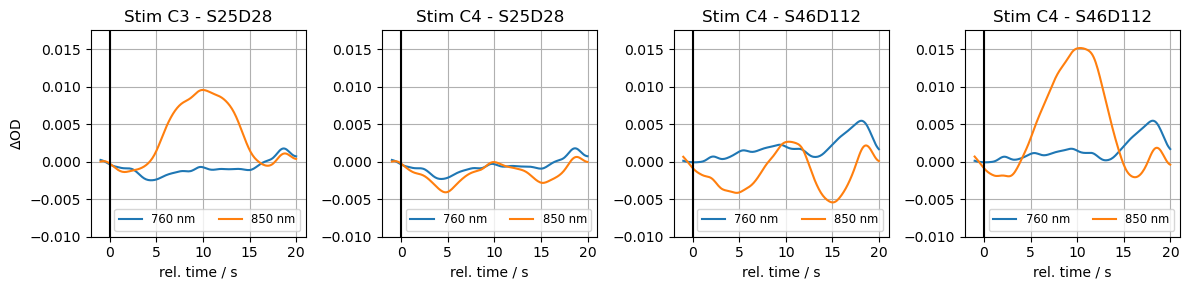

In [22]:
f,ax = p.subplots(1,4, figsize=(12,3))

ax[0].plot(blockaverage.reltime, blockaverage.loc[ch_c3, 760., :, "Stim C3"], label="760 nm")
ax[0].plot(blockaverage.reltime, blockaverage.loc[ch_c3, 850., :, "Stim C3"], label="850 nm")
ax[1].plot(blockaverage.reltime, blockaverage.loc[ch_c3, 760., :, "Stim C4"], label="760 nm")
ax[1].plot(blockaverage.reltime, blockaverage.loc[ch_c3, 850., :, "Stim C4"], label="850 nm")
ax[2].plot(blockaverage.reltime, blockaverage.loc[ch_c4, 760., :, "Stim C3"], label="760 nm")
ax[2].plot(blockaverage.reltime, blockaverage.loc[ch_c4, 850., :, "Stim C3"], label="850 nm")
ax[3].plot(blockaverage.reltime, blockaverage.loc[ch_c4, 760., :, "Stim C4"], label="760 nm")
ax[3].plot(blockaverage.reltime, blockaverage.loc[ch_c4, 850., :, "Stim C4"], label="850 nm")

ax[0].set_title(f"Stim C3 - {ch_c3}")
ax[1].set_title(f"Stim C4 - {ch_c3}")
ax[2].set_title(f"Stim C4 - {ch_c4}")
ax[3].set_title(f"Stim C4 - {ch_c4}")

for i in range(4):
    ax[i].set_ylim(-0.01, 0.0175)
    ax[i].set_xlabel("rel. time / s")
    ax[i].grid()
    ax[i].legend(loc="lower right", ncol=2, fontsize="small")
    ax[i].axvline(0, c="k")
ax[0].set_ylabel("$\Delta$OD")
p.tight_layout()

Save these block-average time series into a snirf file:

In [23]:
OUTPUT_FILE = OUTPUT_FOLDER / "synthetic_hrf.snirf"

rec_save = cdc.Recording()
rec_save["hrf_od"] = blockaverage
rec_save.geo3d = geo3d_relaxed
rec_save.stim = df_stim
cedalion.io.write_snirf(OUTPUT_FILE, rec_save)

## Image Reconstruction

Reload stored HRFs again:

In [24]:
rec_load = cedalion.io.read_snirf(OUTPUT_FILE)[0]

In [25]:
rec_load

<Recording |  timeseries: ['hrf_od'],  masks: [],  stim: ['Stim C3', 'Stim C4'],  aux_ts: [],  aux_obj: []>

In [26]:
rec_load["hrf_od"]

Magnitude,[[[[-0.00019915819926659257 -0.00018006825098576253 -0.00014468446321316142 ... 0.0017153993453994868 0.0017843165959248195 0.0018362543649706534] [-0.00019916470844967872 -0.00018007296872237993 -0.00014468748662126027 ... 0.0017155022678839295 0.0017844206254406837 0.001836359293602963]] [[-0.00028485944883856006 -0.00023860226864167537 -0.00017610184004345872 ... 0.0022115861013148707 0.0023093276921014724 0.0023876000076305933] [-0.00028470718757385785 -0.00023849191246724954 -0.00017603111719930204 ... 0.002209178563006776 0.0023068942583773133 0.0023851455419881353]]] [[[-0.00033547774847055717 -0.00027870657837258245 -0.00020450925545339 ... 0.0012805432033314954 0.0013422834193749964 0.0013819214795026753] [-0.00033547789955004365 -0.0002787066878722259 -0.00020450932562731788 ... 0.0012805455921844784 0.0013422858339223992 0.0013819239149187503]] [[-0.00045080125160321414 -0.0003674378746165143 -0.00026513987215409516 ... 0.0016351550799018587 0.0016919745040842138 0.0017301858705890212] [-0.00045079771758784647 -0.0003674353132269278 -0.00026513823066227904 ... 0.0016350992004182453 0.0016919180235627535 0.0017301289019124612]]] [[[-0.00021356596050394792 -0.0001762948716128234 -0.00012812173286223797 ... 0.0011888893636184678 0.0012953614156400884 0.001397320333858335] [-0.0002135679190954259 -0.00017629629116403556 -0.00012812264259565127 ... 0.0011889203326500392 0.0012953927177737252 0.0013973519065331136]] [[-0.00026750439368951724 -0.0002199150739248968 -0.0001590053963767892 ... 0.0017386624066626822 0.0018582738249804576 0.0019700761548652997] [-0.00026745857878294414 -0.0002198818681201878 -0.00015898411610893332 ... 0.0017379379864311702 0.0018575416129045822 0.001969337614355335]]] ... [[[4.489234181324256e-05 3.579686400157107e-05 2.5505846204448002e-05 ... 0.0010316757965193964 0.0009922343826076288 0.0009594738606938576] [4.489234171012005e-05 3.5796863924812874e-05 2.5505846154096762e-05 ... 0.001031675803668444 0.0009922343897500875 0.0009594738678353429]] [[9.72036272869199e-05 7.618701995204434e-05 5.395785650939178e-05 ... 0.0018380456027940954 0.001784290724083856 0.0017417307285414897] [9.720362969898078e-05 7.618702174744359e-05 5.395785768712389e-05 ... 0.001838045435565297 0.001784290557009257 0.0017417305614897515]]] [[[0.0005890987591017289 0.0004333969057337195 0.00026781760103794175 ... -0.000639694281918567 -0.0009602807033059682 -0.001234343362885993] [0.0005890987396874297 0.00043339684515737937 0.0002678175354736564 ... -0.0006395667315272703 -0.0009601537059693415 -0.0012342167138185125]] [[0.0003208181863200436 0.0002505529714257733 0.00016953523487329595 ... -0.0016277120993831412 -0.0018698075347360096 -0.0020431881203793597] [0.0003208186404553129 0.000250554388413653 0.0001695367685378554 ... -0.0016306957278400726 -0.001872778226269505 -0.00204615066528373]]] [[[-0.00012427172825518507 -0.00010156863755373848 -7.394179272287338e-05 ... 0.000907816069241669 0.0009190236217022882 0.0009348722465372589] [-0.00012427172825821175 -0.00010156863755593155 -7.39417927242785e-05 ... 0.0009078160692895419 0.0009190236217506727 0.0009348722465860598]] [[-0.00020011514028424226 -0.00016068845536814364 -0.00011479366221434 ... 0.0012782525024406972 0.0012812436541051336 0.0012953029355028192] [-0.00020011514021354605 -0.0001606884553169065 -0.000114793662181506 ... 0.0012782525013223145 0.0012812436529747227 0.0012953029343626375]]]]
Units,dimensionless


Estimate channel variances. These will be used to 

In [27]:
c_meas = quality.measurement_variance(rec[OD_NAME].pint.dequantify(), calc_covariance=False)
c_meas

<xarray.DataArray (channel: 497, wavelength: 2)> Size: 8kB
6.944e-05 0.0002514 0.0001554 0.0004173 ... 0.0006236 0.0001824 0.0005278
Coordinates:
  * channel     (channel) object 4kB 'S10D87' 'S10D94' ... 'S47D29' 'S5D137'
    source      (channel) object 4kB 'S10' 'S10' 'S10' ... 'S56' 'S47' 'S5'
    detector    (channel) object 4kB 'D87' 'D94' 'D89' ... 'D129' 'D29' 'D137'
  * wavelength  (wavelength) float64 16B 760.0 850.0

In [28]:
recon = cedalion.dot.ImageRecon(
    Adot.sel(channel=rec_load["hrf_od"].channel),
    recon_mode="mua2conc",
    alpha_meas=0.5,
    brain_only=False,
    spatial_basis_functions=None,
    apply_c_meas=True,
)

recon_img = recon.reconstruct(rec_load["hrf_od"], c_meas=c_meas)

In [29]:
recon_img.sel(chromo="HbO", trial_type="Stim C3", vertex=Adot.is_brain).max().item()

<Quantity(1.3372154945636794, 'micromolar')>

Visualize reconstruction result on the brain.

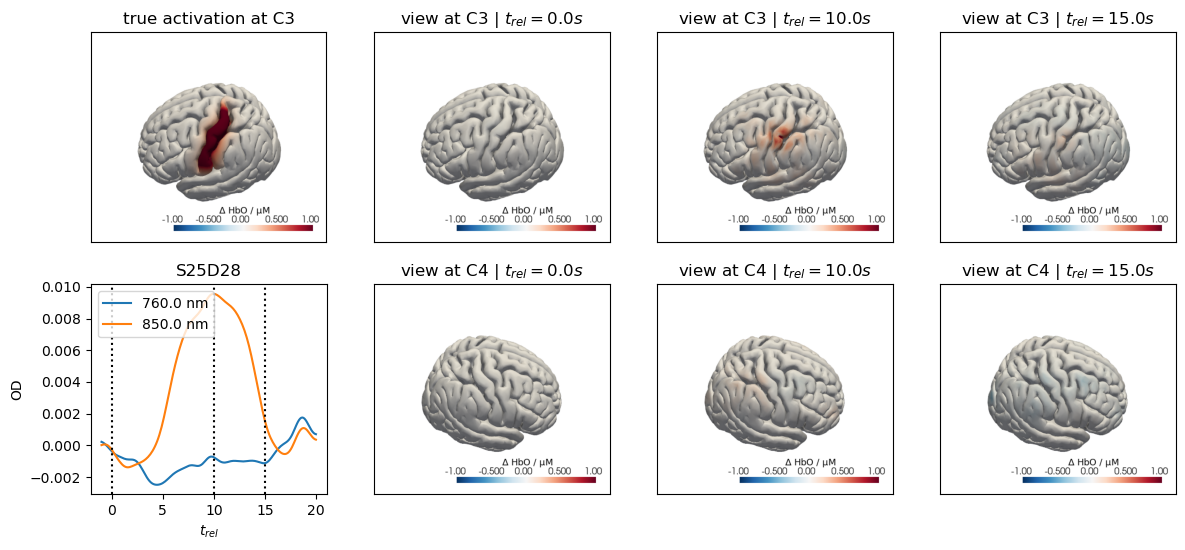

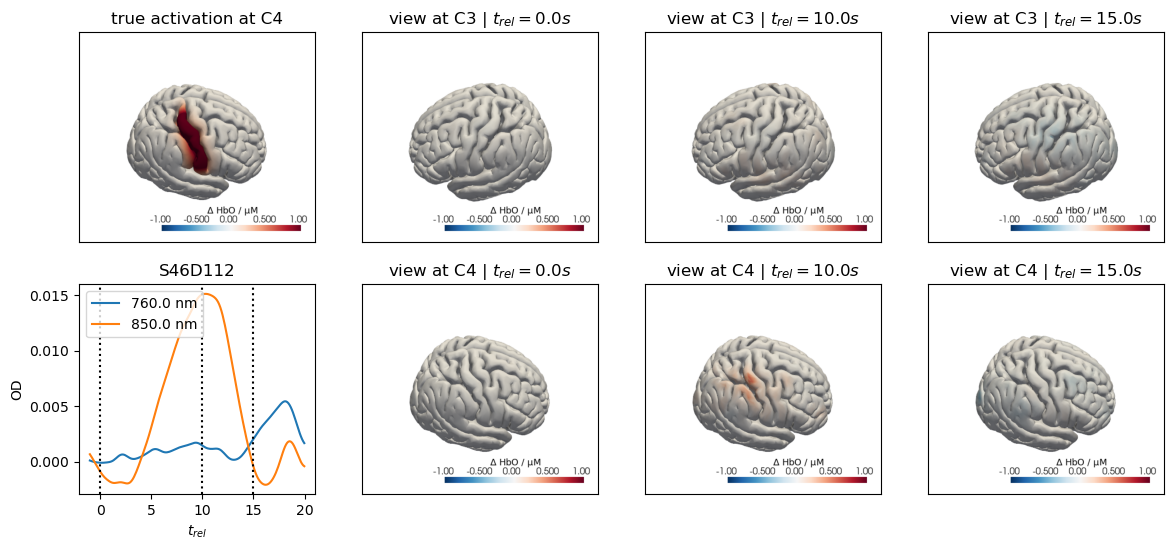

In [30]:
for c, channel in [("C3", ch_c3), ("C4", ch_c4)]:
    trial_type = f"Stim {c}"

    f,ax = p.subplots(2,4, figsize=(14,6))
    vmin,vmax = -1,1

    cedalion.vis.anatomy.plot_brain_in_axes(
        rec_load["hrf_od"],
        head_ras.landmarks,
        spatial_act.sel(trial_type=trial_type, chromo="HbO").pint.to("uM"),
        head_ras.brain,
        ax[0,0],
        camera_pos=c,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        cb_label=r"$\Delta$ HbO / µM",
        #title=f"{c} Activation",
    )
    ax[0,0].set_title(f"true activation at {c}")

    trels = [0., 10., 15.]
    for i_wl, wl in enumerate(rec_load["hrf_od"].wavelength.values):
        tmp = rec_load["hrf_od"].sel(
            trial_type=trial_type, channel=channel, wavelength=wl
        )
        ax[1,0].plot(tmp.time, tmp, label=f"{wl} nm")
    for trel in trels:
        ax[1,0].axvline(trel, c="k", ls=":")
    ax[1,0].legend(loc="upper left")
    ax[1,0].set_xlabel("$t_{rel}$")
    ax[1,0].set_ylabel("OD")
    ax[1,0].set_title(channel)

    for i_col, trel in enumerate(trels, start=1):
        for i_row, cam_pos in enumerate(["C3", "C4"]):
            cedalion.vis.anatomy.plot_brain_in_axes(
                rec_load["hrf_od"],
                head_ras.landmarks,
                recon_img.sel(chromo="HbO", trial_type=trial_type, vertex=Adot.is_brain)
                .sel(time=trel, method="nearest"),
                head_ras.brain,
                ax[i_row, i_col],
                camera_pos=cam_pos,
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                cb_label=r"$\Delta$ HbO / µM",
                #title="$t_{rel}=" + f"{trel:.1f} s$",
            )
            ax[i_row, i_col].set_title(f"view at {cam_pos} | " + "$t_{rel}=" + f"{trel:.1f} s$")

Visualize reconstruction result on the scalp:

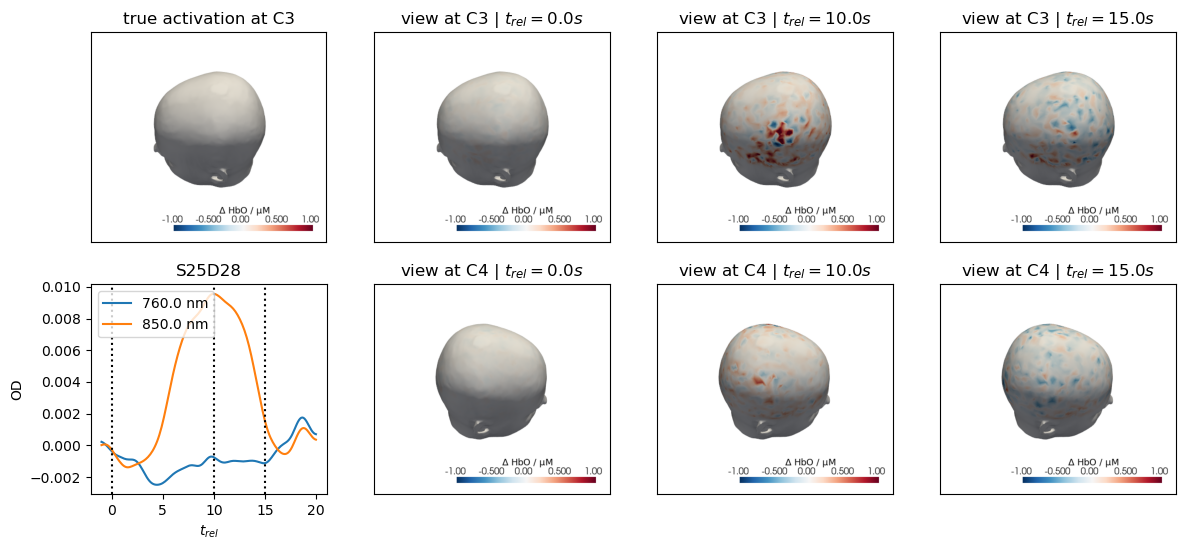

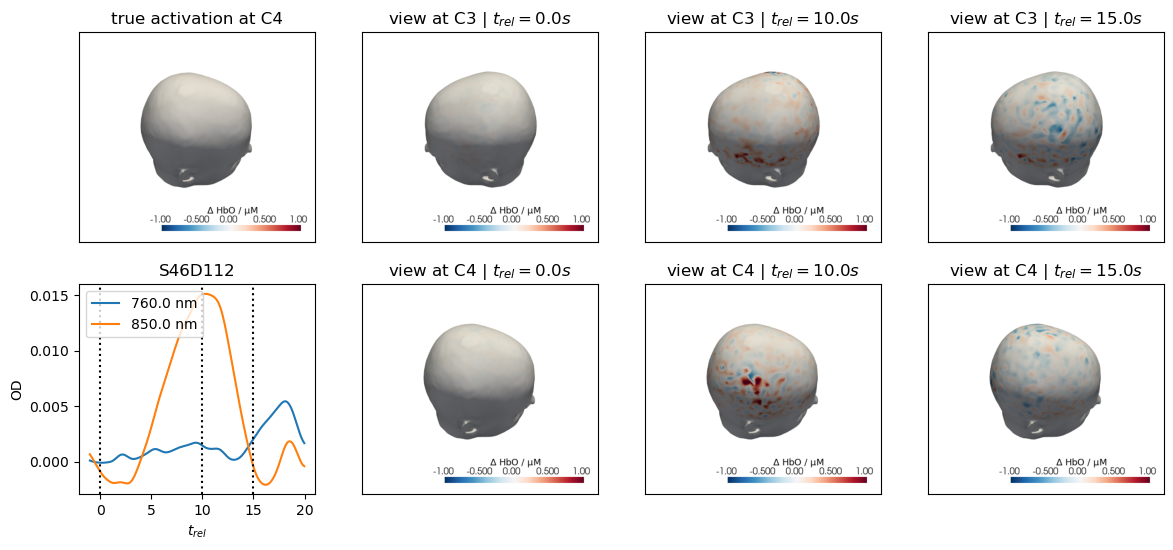

In [31]:
for c, channel in [("C3", ch_c3), ("C4", ch_c4)]:
    trial_type = f"Stim {c}"

    f,ax = p.subplots(2,4, figsize=(14,6))
    vmin,vmax = -1,1

    cedalion.vis.anatomy.plot_brain_in_axes(
        rec_load["hrf_od"],
        head_ras.landmarks,
        xr.DataArray(np.zeros(head_ras.scalp.nvertices), dims="vertex"),
        head_ras.scalp,
        ax[0,0],
        camera_pos=c,
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        cb_label=r"$\Delta$ HbO / µM",
        #title=f"{c} Activation",
    )
    ax[0,0].set_title(f"true activation at {c}")

    trels = [0., 10., 15.]
    for i_wl, wl in enumerate(rec_load["hrf_od"].wavelength.values):
        tmp = rec_load["hrf_od"].sel(
            trial_type=trial_type, channel=channel, wavelength=wl
        )
        ax[1,0].plot(tmp.time, tmp, label=f"{wl} nm")
    for trel in trels:
        ax[1,0].axvline(trel, c="k", ls=":")
    ax[1,0].legend(loc="upper left")
    ax[1,0].set_xlabel("$t_{rel}$")
    ax[1,0].set_ylabel("OD")
    ax[1,0].set_title(channel)

    for i_col, trel in enumerate(trels, start=1):
        for i_row, cam_pos in enumerate(["C3", "C4"]):
            cedalion.vis.anatomy.plot_brain_in_axes(
                rec_load["hrf_od"],
                head_ras.landmarks,
                recon_img.sel(chromo="HbO", trial_type=trial_type, vertex=~Adot.is_brain)
                .sel(time=trel, method="nearest"),
                head_ras.scalp,
                ax[i_row, i_col],
                camera_pos=cam_pos,
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                cb_label=r"$\Delta$ HbO / µM",
                #title="$t_{rel}=" + f"{trel:.1f} s$",
            )
            ax[i_row, i_col].set_title(f"view at {cam_pos} | " + "$t_{rel}=" + f"{trel:.1f} s$")

In [32]:
# store dynamically generated mappings in matrix market format
#import scipy.io
#scipy.io.mmwrite(OUTPUT_FOLDER / "hm_icbm152/voxel_to_vertex_brain.mtx",  head_ras.voxel_to_vertex_brain)
#scipy.io.mmwrite(OUTPUT_FOLDER / "hm_icbm152/voxel_to_vertex_scalp.mtx",  head_ras.voxel_to_vertex_scalp)